In [6]:
import pandas as pd
import numpy as np
import math
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

In [56]:
def OCV_curve():
    soc_points = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 
              55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

    ocv_points = [3.00, 3.13, 3.40, 3.55, 3.62, 3.66, 3.68, 3.70, 
                  3.71, 3.72, 3.73, 3.74, 3.75, 3.77, 3.80, 3.84, 
                  3.90, 3.98, 4.06, 4.14, 4.20]

    cs = CubicSpline(soc_points, ocv_points)
    return cs
    

def get_SOC(SOC, I, C, t):
    return SOC - ((I * t) / C)

def get_voltage(SOC, I, R0, cs, tV):
    return cs(SOC * 100).item() - I * R0 - tV

def get_tvoltage(t, VRC, I, R, C):
    exp = math.exp(-t / (R * C))
    return exp*VRC + R*(1-exp)*I


def execute(SOC, V, VRC):
    #setup
    #plot
    soc_true_hist = []
    soc_est_hist = []
    time_hist = []
    true_SOC = 1
    true_VRC = 0
    
    plt.ion()
    fig, ax = plt.subplots()
    line1, = ax.plot([], [], label="True SOC")
    line2, = ax.plot([], [], label="Estimated SOC")
    ax.legend()

    #values
    cs = OCV_curve()
    t = 0
    tstep = 0.5
    C = 0.820 * 3600 
    true_I = 0.8
    error_I = true_I * 0.02 #std
    R0 = 0.02
    R1 = 0.03
    C1 = 2000
    P = np.array([
        [0.01, 0],
        [0,    0.001]
    ])
    
    Q = np.array([
        [1e-8, 0],
        [0,    1e-5]
    ])
    
    R = np.array([[0.0064]])
        
    while(true_SOC > 0.10):
        #EKF preparation
        # controller decides load based on estimated SOC
        if SOC > 0.7:
            true_I = 1.126
        elif SOC > 0.4:
            true_I = 0.484
        else:
            true_I = 0.182
        
        # current sensor reading
        error_I = true_I * 0.02
        actual_I = true_I + np.random.normal(0, error_I)
        
        
        #true SOC + VRC
        true_SOC = get_SOC(true_SOC, true_I, C, tstep) 
        true_VRC = get_tvoltage(tstep, true_VRC, true_I, R1, C1)


        #voltage
        measured_V = get_voltage(true_SOC, true_I, R0, cs, true_VRC)
        error_V = measured_V * 0.02 #std
        measured_V = measured_V + np.random.normal(0, error_V)

    
        #EKF equations
        #predict step
        A = np.array([[1, 0], [0, math.exp(-tstep/ (R1 * C1))]])
        new_SOC = get_SOC(SOC, actual_I, C, tstep)
        new_VRC = get_tvoltage(tstep, VRC, actual_I, R1, C1)
        H = np.array([[cs(new_SOC, nu=1).item(), -1]])
        pred_error = A @ P @ A.T + Q

        #measure step  
        #pred voltage
        pred_voltage = get_voltage(new_SOC, actual_I, R0, cs, new_VRC)

        #innovation
        y = measured_V - pred_voltage

        #kalman gain
        S = (H @ pred_error @ H.T + R)
        K = (pred_error @ H.T) @ (np.linalg.inv(S))
        new_values = np.array([[new_SOC], [new_VRC]])
        #final SOC estimation + error estimation
        values = new_values + K * y
        SOC = values[0, 0]
        VRC = values[1, 0]

        I = np.eye(2)
        P = (I - K @ H) @ pred_error
    
        time_hist.append(t + tstep)

        soc_true_hist.append(float(true_SOC))
        soc_est_hist.append(float(SOC))
    
        line1.set_data(time_hist, soc_true_hist)
        line2.set_data(time_hist, soc_est_hist)
    
        ax.relim()
        ax.autoscale_view()
    
        plt.draw()


        t = t + tstep

    print("SIMULATION: SUCCESSFUL")
        
  

SIMULATION: SUCCESSFUL


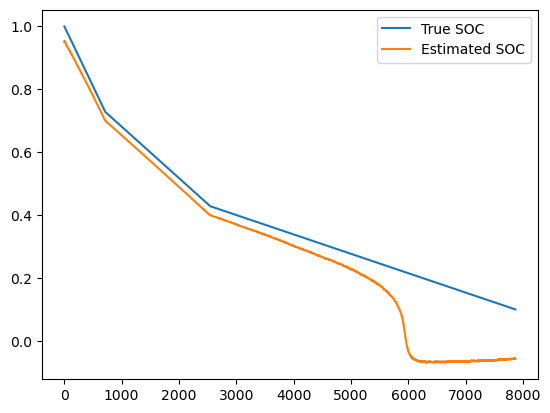

In [57]:
execute(0.95, 4.2, 0)

In [ ]:
# generate smooth SOC values
x_smooth = np.linspace(0, 100, 500)
cs = OCV_curve()
# evaluate spline
y_smooth = cs(x_smooth)
soc_points = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 
              55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

ocv_points = [3.00, 3.13, 3.40, 3.55, 3.62, 3.66, 3.68, 3.70, 
                  3.71, 3.72, 3.73, 3.74, 3.75, 3.77, 3.80, 3.84, 
                  3.90, 3.98, 4.06, 4.14, 4.20]
# plot
plt.plot(x_smooth, y_smooth, label="Spline")
plt.scatter(soc_points, ocv_points, color='red', label="Data points")

plt.xlabel("SOC (%)")
plt.ylabel("OCV (V)")
plt.legend()
plt.show()